# SMACNP Predictions — Combined ERA5 + PeakWeather Context

Loads trained SMACNP models and evaluates predictions on holdout PeakWeather
test stations.

## What this notebook does

For each cross-validation fold:
1. Loads the trained model checkpoint for that fold.
2. Identifies the holdout time period (a contiguous fifth of the common date range).
3. Builds the **combined context** for every holdout day:
   - ERA5 reanalysis grid (~1769 cells, source flag = 0)
   - PeakWeather train stations (~137 stations, source flag = 1)
4. Predicts temperature (mean μ and uncertainty σ) at the **35 held-out PeakWeather
   test stations** — stations never used as context during training.
5. Compares against a regression kriging baseline (Universal Kriging with linear drift).

After all folds, the non-overlapping holdout periods are concatenated to give a
full-year evaluation:
- Per-station error maps (MAE, RMSE, Bias)
- CRPS and skill score vs regression kriging baseline
- Uncertainty calibration (Q-Q plot, reliability diagram)
- Error correlations with altitude, mTPI, and day of year

## Ground truth

Predictions are evaluated against raw **PeakWeather observations** at the test
stations. All temperatures are in °C after denormalisation
using the ERA5 statistics saved in `metadata.json`.


In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
MODEL_NAME = 'test-combined-era5-pw-mean-11'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99
STATION_SPLIT_SEED = 42   # must match training notebook exactly


In [3]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_crps.py:257: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z (F(z) - H(z - x))^2 dz
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:10: SyntaxWarning: invalid escape sequence '\i'
  The Brier score (BS) scores binary forecasts $k \in \{0, 1\}$,
/home/renku/work/.venv/lib/python3.13/site-packages/properscoring/_brier.py:102: SyntaxWarning: invalid escape sequence '\i'
  CRPS(F, x) = \int_z BS(F(z), H(z - x)) dz


In [4]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [5]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_MEAN_TEMP_GLOB = './datasets/ERA5_Land/temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'
DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'

In [6]:
# Build plot output directory and filename prefix
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    return PLOT_DIR / f"{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: trained_models/test-combined-era5-pw-mean-11/plots


## Load Training Configuration

In [7]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_MAX_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
ERA5_MEAN_TEMP_GLOB = params.ERA5_MEAN_TEMP_GLOB or DEFAULT_ERA5_MEAN_TEMP_GLOB
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
METEO_SWISS_MAX_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH
METEO_SWISS_MEAN_TEMP_GLOB = getattr(params, 'METEO_SWISS_MEAN_TEMP_GLOB', None) or DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB


print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_MAX_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_MAX_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: test-combined-era5-pw-mean-11
  Variable: tmax
  Data year start: 2023
  N folds: 1
  Model: 128 channels, 6 blocks
  ERA5 max temp: datasets/ERA5_Land/max_temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  MeteoSwiss: datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc
  Topography: datasets/topo_subset.zarr


In [8]:
if params.TEMPERATURE_TYPE == 'max':
    _era5_glob = ERA5_MAX_TEMP_GLOB
    _era5_var  = 't2m_max'
else:
    _era5_glob = ERA5_MEAN_TEMP_GLOB   # from DEFAULT or saved params
    _era5_var  = 't2m'

era5_tensor_pred, era5_metadata_local, era5_grid_elevation, time_coords_era5 = ds.load_era5_data(
    _era5_glob,
    var_name=_era5_var,
    year_start=None,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    include_seasonal_embeddings=True,
    device=device,
)
era5_dates_pd = pd.DatetimeIndex(pd.to_datetime(time_coords_era5).date.astype(str))
x_era5, y_era5 = ds.build_smacnp_context(era5_tensor_pred)
print(f"ERA5: {x_era5.shape}, dates {era5_dates_pd[0]} → {era5_dates_pd[-1]}")


Loading ERA5 data from: datasets/ERA5_Land/temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([23376, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 grid points are subset of geopotential grid (using near

## Load Data

In [9]:
# Load PeakWeather stations (same params as training)
daily_tmean, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)

daily_tmean.index = daily_tmean.index - pd.Timedelta(days=1)
pw_dates_pd = pd.DatetimeIndex(daily_tmean.index.date.astype(str))

# Reproduce the same station split used during training
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=params.PW_TRAIN_FRAC,
    val_frac=params.PW_VAL_FRAC,
    seed=STATION_SPLIT_SEED,
)
print(f"Test stations: {len(test_stations)}")

# Seasonal features
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
else:
    seasonal_features = None

# Hi-res topography (for mTPI features)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

tpi_abs_max = float(max(
    abs(float(hi_res_tpi.min())),
    abs(float(hi_res_tpi.max()))
))
print(f"TPI abs max: {tpi_abs_max:.1f} m")


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Station split: 137 train / 0 val / 35 test
Test stations: 35
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32
TPI abs max: 408.0 m


In [10]:
common_dates = pw_dates_pd.intersection(era5_dates_pd)
era5_idx = np.array([era5_dates_pd.get_loc(d) for d in common_dates])
pw_idx   = np.array([pw_dates_pd.get_loc(d)   for d in common_dates])

x_era5_aligned = x_era5[era5_idx]
y_era5_aligned = y_era5[era5_idx]

y_era5_aligned = y_era5_aligned * era5_metadata_local.data_std + era5_metadata_local.data_mean
y_era5_aligned = (y_era5_aligned - metadata.data_mean) / metadata.data_std

pw_times_np_common = np.array(common_dates, dtype='datetime64[D]')
seasonal_features_aligned = ds.compute_seasonal_features(pw_times_np_common, device=device)
common_dates_pd = common_dates
T_common = len(common_dates_pd)
print(f"Common dates: {T_common} ({common_dates_pd[0]} → {common_dates_pd[-1]})")

Computed seasonal features: torch.Size([2557, 2]), dtype: torch.float32
Common dates: 2557 (2016-12-31 00:00:00 → 2023-12-31 00:00:00)


In [11]:
x_pw_train, y_pw_train = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    seasonal_features=seasonal_features_aligned,
    dates_pd=common_dates_pd,
    device=device,
)
y_pw_train = y_pw_train.unsqueeze(-1)
y_pw_train = torch.nan_to_num(y_pw_train, nan=0.0)

In [12]:
x_context, y_context = ds.build_combined_context(
    x_era5_aligned, y_era5_aligned,
    x_pw_train, y_pw_train,
)
print(f"x_context: {x_context.shape}  # (T_common, 1769+{len(train_stations)}, 7)")

x_context: torch.Size([2557, 1906, 7])  # (T_common, 1769+137, 7)


In [13]:
x_target_static = ds.prepare_peakweather_targets(
    stations_meta=stations_meta.loc[test_stations],
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    device=device,
)
n_test = x_target_static.shape[0]

def make_x_target_day(common_day_idx: int) -> torch.Tensor:
    # common_day_idx indexes into common_dates_pd (aligned time axis)
    seas = seasonal_features_aligned[common_day_idx].unsqueeze(0).expand(n_test, -1)
    return torch.cat([x_target_static, seas], dim=-1)   # (n_test, 6)

In [14]:
# Ground truth: PW test station observations on common dates
y_true_all = daily_tmean.reindex(index=common_dates_pd)[test_stations].values
# shape: (T_common, n_test), in °C, NaN where missing

In [15]:
COMPUTE_KRIGING = False   # set to False to skip (predictions still work, skill score N/A)
KRIGING_DEFAULT = 1.0     # constant baseline value used when COMPUTE_KRIGING=False (°C)

if COMPUTE_KRIGING:
    print("Computing regression kriging baseline (this may take a few minutes)...")
    all_baselines = inf.compute_kriging_baseline(
        daily_tmax=daily_tmean,
        train_stations=train_stations,
        test_stations=test_stations,
        stations_meta=stations_meta,
        dates_pd=common_dates_pd,
    )
    print(f"Baseline shape: {all_baselines.shape}  # (n_days_total, n_test_stations)")
else:
    all_baselines = np.full((len(common_dates_pd), len(test_stations)), KRIGING_DEFAULT, dtype=np.float32)
    print(f"Kriging skipped — constant baseline {KRIGING_DEFAULT}°C used.")
    print("MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.")


Kriging skipped — constant baseline 1.0°C used.
MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Fold 1/1
Built SMACNP with 3,179,459 trainable parameters
  Loaded epoch 26 | holdout 2016-12-31 00:00:00 → 2023-12-31 00:00:00


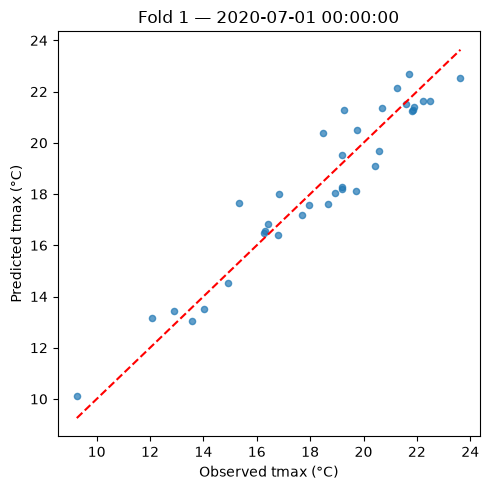

  Fold 1 done: 2557 days

Combined: 2557 days × 35 test stations


In [16]:
n_samples = T_common
combined_preds, combined_sigmas, combined_truths, combined_dates = [], [], [], []
combined_baselines = []

for fold in range(params.N_FOLDS):
    print(f"{'='*60}\nFold {fold+1}/{params.N_FOLDS}\n{'='*60}")

    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue

    model, epoch = model_factory.load_model_checkpoint(
        checkpoint_path, params, device, input_dim=6, context_input_dim=7, 
    )
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    print(f"  Loaded epoch {epoch} | holdout {common_dates_pd[holdout_start]} → {common_dates_pd[holdout_end-1]}")

    fold_preds, fold_sigmas, fold_truths, fold_dates = [], [], [], []
    fold_baselines = []

    with torch.no_grad():
        for common_day_idx in range(holdout_start, holdout_end):
            date = common_dates_pd[common_day_idx]

            # CHANGED: ground truth from PW directly
            true_vals = y_true_all[common_day_idx]
            if np.all(np.isnan(true_vals)):
                continue


            xc = x_context[common_day_idx:common_day_idx+1].to(device)   # (1, 1872, 7)
            yc = y_context[common_day_idx:common_day_idx+1].to(device)   # (1, 1872, 1)
            xt = make_x_target_day(common_day_idx).unsqueeze(0)           # (1, n_test, 6)

            out = model(xc, yc, xt)                                        # (1, n_test, 2)
            mu_norm    = out[0, :, 0].cpu().numpy()
            sigma_norm = out[0, :, 1].cpu().numpy()

            preds_degC = metadata.denormalize(
                torch.tensor(mu_norm)
            ).numpy() - ds.KELVIN_OFFSET

            fold_preds.append(preds_degC)
            fold_sigmas.append(sigma_norm)
            fold_truths.append(true_vals)
            fold_dates.append(date)
            fold_baselines.append(all_baselines[common_day_idx])

    if not fold_preds:
        print(f"  No data — skipping")
        continue

    # Single-day scatter plot
    mid = len(fold_preds) // 2
    valid = ~np.isnan(fold_truths[mid])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(fold_truths[mid][valid], fold_preds[mid][valid], alpha=0.7, s=20)
    lims = [min(fold_truths[mid][valid].min(), fold_preds[mid][valid].min()),
            max(fold_truths[mid][valid].max(), fold_preds[mid][valid].max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Observed tmax (°C)'); ax.set_ylabel('Predicted tmax (°C)')
    ax.set_title(f'Fold {fold+1} — {fold_dates[mid]}')
    plt.tight_layout(); plt.savefig(plot_path(f'fold{fold}_scatter')); plt.show()

    combined_preds.append(np.stack(fold_preds))
    combined_sigmas.append(np.stack(fold_sigmas))
    combined_truths.append(np.stack(fold_truths))
    combined_dates.extend(fold_dates)
    combined_baselines.append(np.stack(fold_baselines))
    print(f"  Fold {fold+1} done: {len(fold_preds)} days")

all_preds   = np.concatenate(combined_preds,  axis=0)
all_sigmas  = np.concatenate(combined_sigmas, axis=0)
all_truths  = np.concatenate(combined_truths, axis=0)
all_errors  = all_preds - all_truths
sigma_degC  = all_sigmas * metadata.data_std
all_baselines_holdout = np.concatenate(combined_baselines, axis=0)
total_days  = all_preds.shape[0]
print(f"\nCombined: {total_days} days × {all_preds.shape[1]} test stations")


## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Overall MAE:          1.034 °C
Overall RMSE:         1.368 °C
Overall Bias:         0.194 °C
Overall CRPS:         0.755 °C
Global skill score:   0.913


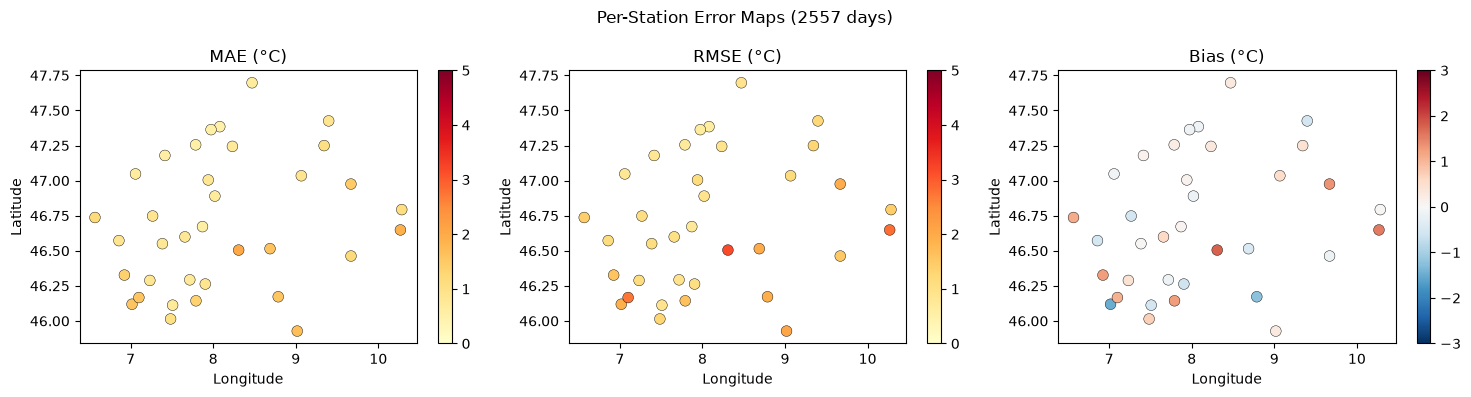

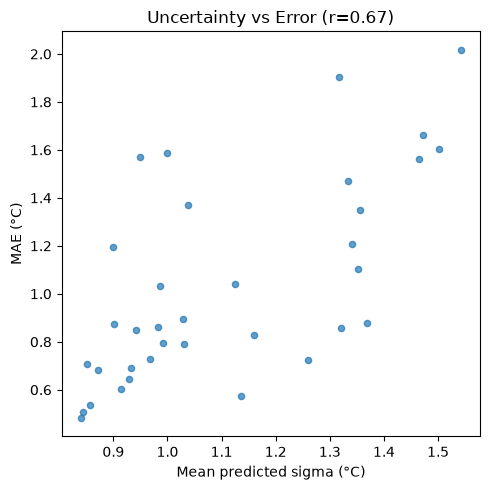

Per-station uncertainty-error correlation: 0.667


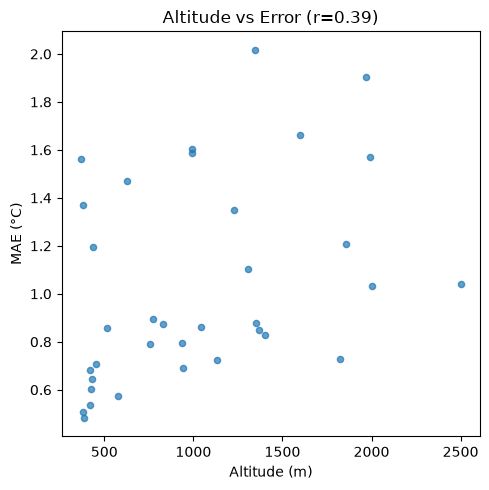

Altitude-error correlation: 0.387


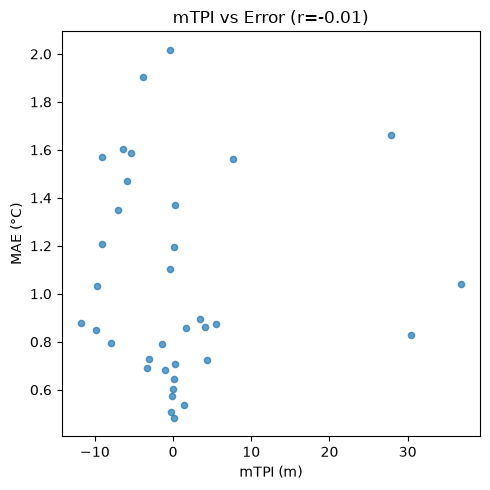

mTPI-error correlation: -0.013
  Saved plot: trained_models/test-combined-era5-pw-mean-11/plots/doy_vs_error.png


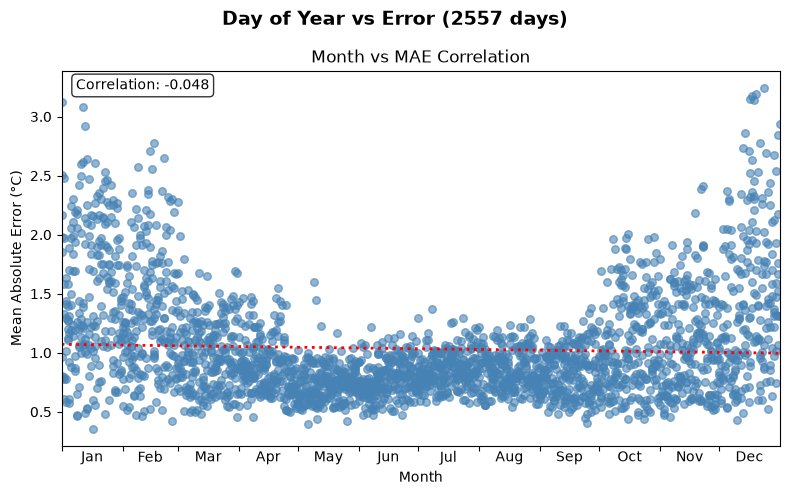

Day of year-error correlation: -0.048


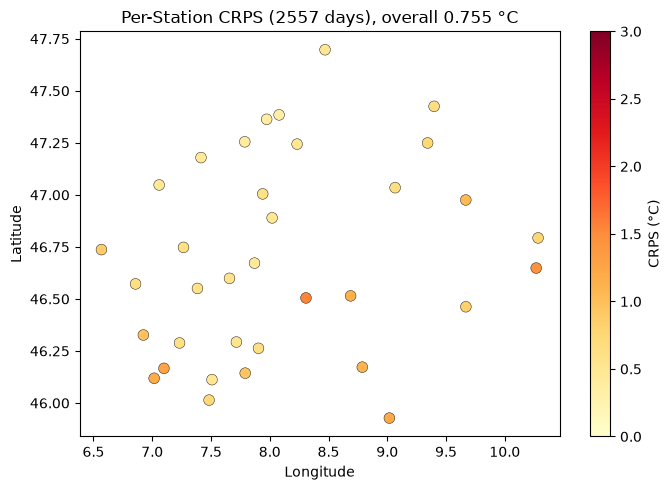

  Saved plot: trained_models/test-combined-era5-pw-mean-11/plots/skill_map.png


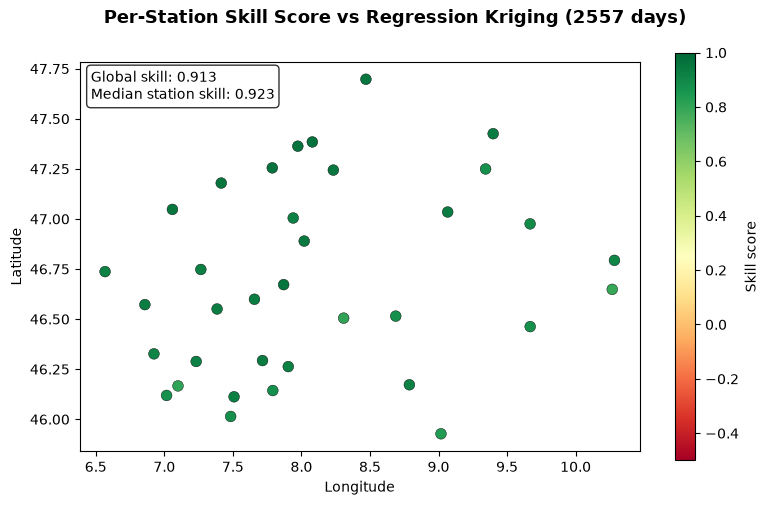

Saved station metrics to trained_models/test-combined-era5-pw-mean-11/station_metrics.npz


In [17]:
station_lats = stations_meta.loc[test_stations, 'latitude'].values
station_lons = stations_meta.loc[test_stations, 'longitude'].values
station_alts = stations_meta.loc[test_stations, 'station_height'].values
station_tpi  = (x_target_static[:, 3].cpu().numpy() * 400.0) - 200.0  # denorm mTPI

m = metrics.compute_station_metrics(
    all_errors=all_errors,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    all_truths=all_truths,
    all_ref_preds=all_baselines_holdout,
)

mae_per_station   = m.mae
rmse_per_station  = m.rmse
bias_per_station  = m.bias
crps_per_station  = m.crps
sigma_per_station = m.mean_sigma

kriging_errors = all_baselines_holdout - all_truths   # already in °C
kriging_mae    = np.nanmean(np.abs(kriging_errors))
kriging_rmse   = np.sqrt(np.nanmean(kriging_errors**2))
kriging_bias   = np.nanmean(kriging_errors)

print(f"Overall MAE:          {np.nanmean(mae_per_station):.3f} °C")
print(f"Overall RMSE:         {np.nanmean(rmse_per_station):.3f} °C")
print(f"Overall Bias:         {np.nanmean(bias_per_station):.3f} °C")
print(f"Overall CRPS:         {m.overall_crps:.3f} °C")
print(f"Global skill score:   {m.global_skill:.3f}")

# 1. Station error map
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title, cmap, vmin, vmax in zip(
    axes,
    [mae_per_station, rmse_per_station, bias_per_station],
    ['MAE (°C)', 'RMSE (°C)', 'Bias (°C)'],
    ['YlOrRd', 'YlOrRd', 'RdBu_r'],
    [0, 0, -3], [5, 5, 3],
):
    sc = ax.scatter(station_lons, station_lats, c=vals, cmap=cmap,
                    vmin=vmin, vmax=vmax, s=60, edgecolors='k', linewidths=0.3)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
fig.suptitle(f'Per-Station Error Maps ({total_days} days)')
plt.tight_layout()
plt.savefig(plot_path('error_maps'))
plt.show()

# 2. Uncertainty vs error (per station)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sigma_per_station, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Mean predicted sigma (°C)')
ax.set_ylabel('MAE (°C)')
corr = np.corrcoef(sigma_per_station, mae_per_station)[0, 1]
ax.set_title(f'Uncertainty vs Error (r={corr:.2f})')
plt.tight_layout()
plt.savefig(plot_path('uncertainty_vs_error'))
plt.show()
print(f"Per-station uncertainty-error correlation: {corr:.3f}")

# 3. Altitude vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_alts, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('MAE (°C)')
corr_alt = np.corrcoef(station_alts, mae_per_station)[0, 1]
ax.set_title(f'Altitude vs Error (r={corr_alt:.2f})')
plt.tight_layout()
plt.savefig(plot_path('altitude_vs_error'))
plt.show()
print(f"Altitude-error correlation: {corr_alt:.3f}")

# 4. mTPI vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_tpi, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('mTPI (m)')
ax.set_ylabel('MAE (°C)')
corr_tpi = np.corrcoef(station_tpi, mae_per_station)[0, 1]
ax.set_title(f'mTPI vs Error (r={corr_tpi:.2f})')
plt.tight_layout()
plt.savefig(plot_path('mtpi_vs_error'))
plt.show()
print(f"mTPI-error correlation: {corr_tpi:.3f}")

# 5. Day of year vs error (reuses existing visualization function)
all_holdout_dates = np.array(combined_dates, dtype='datetime64')
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors,
    holdout_dates=all_holdout_dates,
    title=f'Day of Year vs Error ({total_days} days)',
    save_path=plot_path('doy_vs_error'),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS station map
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(station_lons, station_lats, c=crps_per_station,
                cmap='YlOrRd', vmin=0, vmax=3, s=60,
                edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='CRPS (°C)')
ax.set_title(f'Per-Station CRPS ({total_days} days), '
             f'overall {np.nanmean(crps_per_station):.3f} °C')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(plot_path('crps_map'))
plt.show()

# 7. Skill score map
fig_skill = vis.plot_station_skill_map(
    skill_per_station=m.skill,
    station_lats=station_lats,
    station_lons=station_lons,
    global_skill=m.global_skill,
    title=f'Per-Station Skill Score vs Regression Kriging ({total_days} days)',
    save_path=plot_path('skill_map'),
)
plt.show()

station_metrics_path = MODEL_DIR / 'station_metrics.npz'
np.savez(station_metrics_path,
         mae=mae_per_station, rmse=rmse_per_station,
         crps=crps_per_station, lats=station_lats, lons=station_lons)
print(f"Saved station metrics to {station_metrics_path}")

  Saved plot: trained_models/test-combined-era5-pw-mean-11/plots/qq_calibration.png


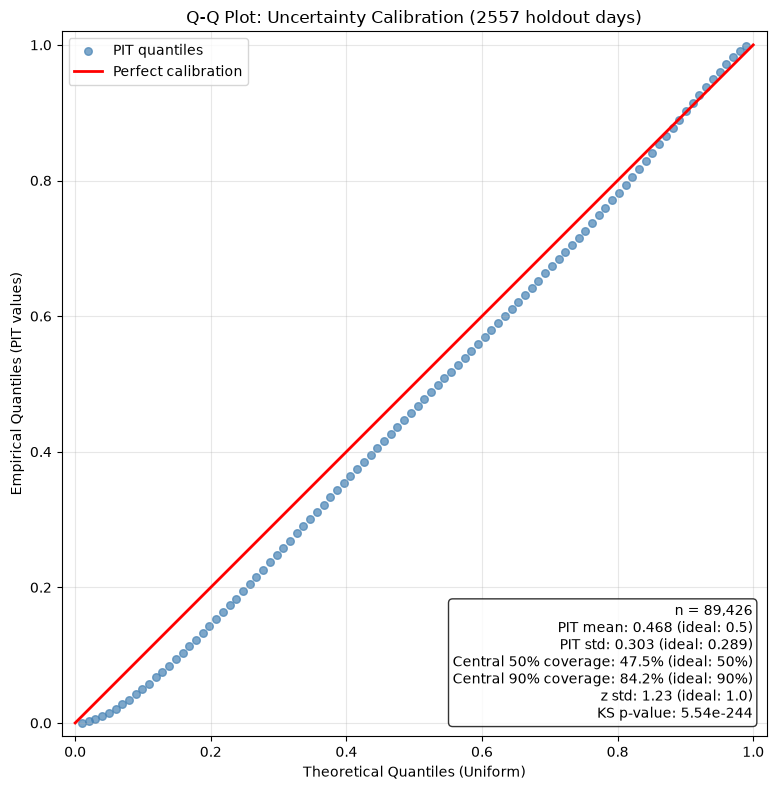


Calibration statistics:
  PIT mean: 0.468 (ideal: 0.5)
  PIT std:  0.303 (ideal: 0.289)
  z std:    1.23 (ideal: 1.0)
  50% coverage: 47.5% (ideal: 50%)
  90% coverage: 84.2% (ideal: 90%)
  KS test p-value: 5.54e-244


In [18]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/test-combined-era5-pw-mean-11/plots/reliability_diagram.png


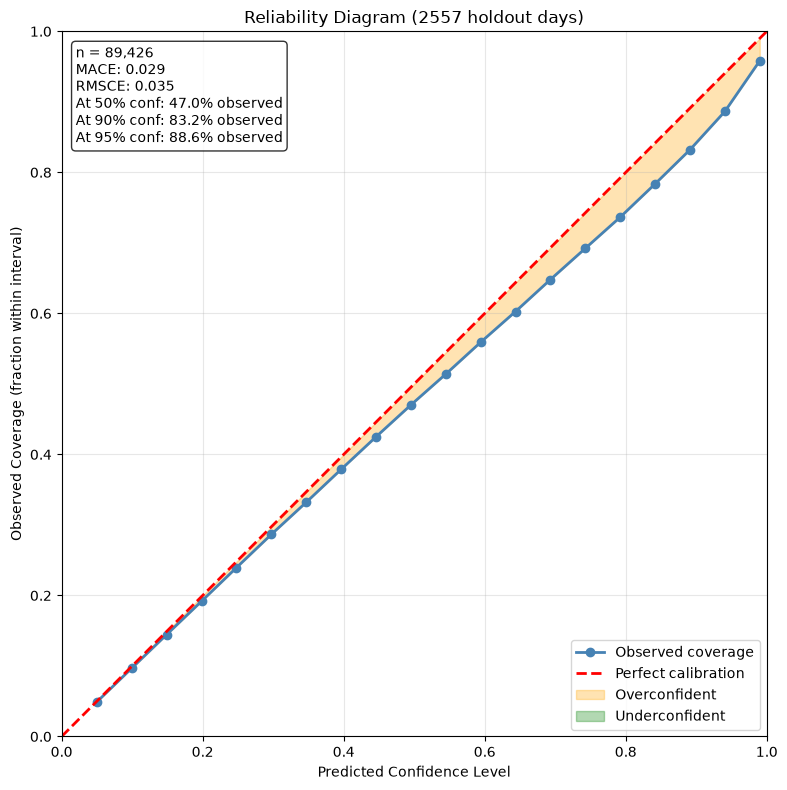


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.029
  At 50% confidence: 47.0% observed (ideal: 50%)
  At 90% confidence: 83.2% observed (ideal: 90%)
  At 95% confidence: 88.6% observed (ideal: 95%)


In [19]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

In [20]:
import json

metrics_path = MODEL_DIR / 'metrics.json'

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "inference_dataset": "peakweather_test_stations",
        "context": "combined_era5_and_pw_train_stations",
        "n_context_stations": len(train_stations),
        "n_test_stations": len(test_stations),
        "station_split_seed": STATION_SPLIT_SEED,
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
        "pw_first_date": PW_FIRST_DATE,
        "pw_last_date": PW_LAST_DATE,
        "pw_validity_threshold": PW_VALIDITY_THRESHOLD,
    },
    "overall": {
        "mae":  float(np.nanmean(mae_per_station)),
        "rmse": float(np.nanmean(rmse_per_station)),
        "bias": float(np.nanmean(bias_per_station)),
        "crps": float(np.nanmean(crps_per_station)),
        "skill_score": float(m.global_skill),
    },
    "correlations": {
        "uncertainty_error": float(corr),
        "altitude_error":    float(corr_alt),
        "mtpi_error":        float(corr_tpi),
        "doy_error":         float(doy_corr),
    },
    "calibration": {
        "pit_mean":    float(calibration_stats["pit_mean"]),
        "pit_std":     float(calibration_stats["pit_std"]),
        "z_std":       float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value":  float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace":            float(reliability_stats["mace"]),
        "coverage_at_50":  float(reliability_stats["coverage_at_50"]),
        "coverage_at_90":  float(reliability_stats["coverage_at_90"]),
        "coverage_at_95":  float(reliability_stats["coverage_at_95"]),
    },
}
metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/test-combined-era5-pw-mean-11/metrics.json


In [21]:
# Per-station summary table: altitude, MAE, RMSE, Bias — sorted by MAE
station_table = pd.DataFrame(
    {
        'Name':         stations_meta.loc[test_stations, 'station_name'].values,
        'Altitude (m)': station_alts.astype(int),
        'MAE (°C)':     np.round(mae_per_station, 3),
        'RMSE (°C)':    np.round(rmse_per_station, 3),
        'Bias (°C)':    np.round(bias_per_station, 3),
    },
    index=test_stations,
).sort_values('MAE (°C)')

print(f"Per-station metrics for {len(test_stations)} test stations (sorted by MAE):\n")
display(station_table)

Per-station metrics for 35 test stations (sorted by MAE):



,Name,Altitude (m),MAE (°C),RMSE (°C),Bias (°C)
BUS,Buchs / Aarau,386,0.482,0.634,-0.129
GOE,Gösgen,380,0.509,0.669,-0.132
WYN,Wynau,421,0.535,0.704,0.216
INT,Interlaken,577,0.575,0.748,0.078
GRE,Grenchen,427,0.603,0.815,0.122
CRM,Cressier,430,0.645,0.813,-0.110
HLL,Hallau,419,0.682,0.914,0.298
FLU,"Flühli, LU",939,0.691,0.912,-0.176
MOA,Mosen,453,0.708,0.914,0.325
VSERG,Ergisch,1133,0.726,0.906,-0.158


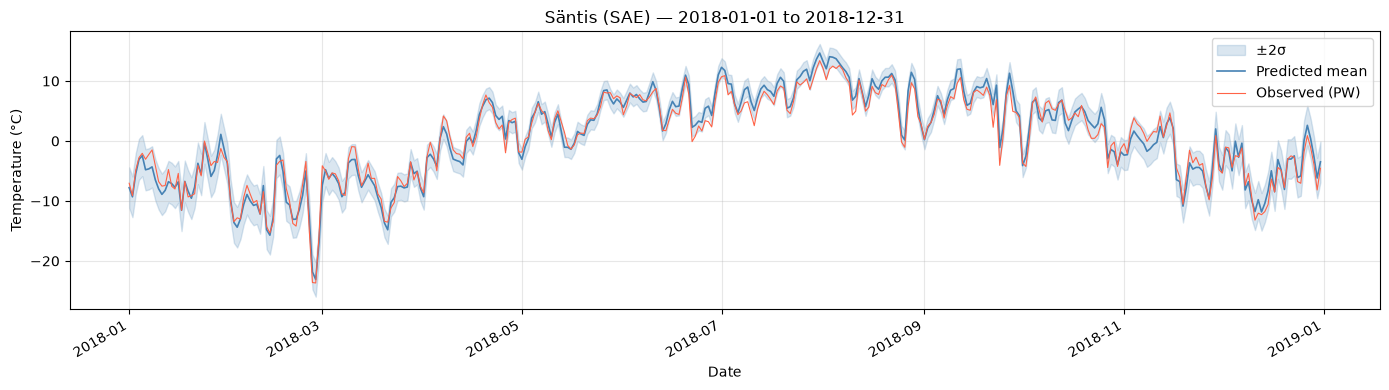

In [22]:
# ── Time-series plot: predicted vs observed for a single station ────────────
STATION_CODE  = 'SAE'
DATE_START    = '2018-01-01'
DATE_END      = '2018-12-31'

# Locate the station index among test stations
station_idx = list(test_stations).index(STATION_CODE)
station_name = stations_meta.loc[STATION_CODE, 'station_name']

# Filter to the requested date window (combined_dates may be non-contiguous across folds)
dates_arr = pd.DatetimeIndex(combined_dates)
mask = (dates_arr >= DATE_START) & (dates_arr <= DATE_END)
dates_plot  = dates_arr[mask]
preds_plot  = all_preds[mask, station_idx]
sigma_plot  = sigma_degC[mask, station_idx]
truths_plot = all_truths[mask, station_idx]

fig, ax = plt.subplots(figsize=(14, 4))

# Uncertainty band: mean ± 2σ
ax.fill_between(
    dates_plot,
    preds_plot - 2 * sigma_plot,
    preds_plot + 2 * sigma_plot,
    alpha=0.2, color='steelblue', label='±2σ',
)

# Predicted mean and observations
ax.plot(dates_plot, preds_plot, color='steelblue', linewidth=1.2, label='Predicted mean')
ax.plot(dates_plot, truths_plot, color='tomato', linewidth=0.8, label='Observed (PW)')


ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'{station_name} ({STATION_CODE}) — {DATE_START} to {DATE_END}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [23]:
# Load one fold's model without running the full prediction loop
grid_shape = (240, 370)

fold = 0   # any fold works for attention visualization
checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
model, epoch = model_factory.load_model_checkpoint(
    checkpoint_path, params, device, input_dim=6, context_input_dim=7
)
print(f"Loaded model from fold {fold}, epoch {epoch}")

Built SMACNP with 3,179,459 trainable parameters
Loaded model from fold 0, epoch 26


In [24]:
# --- Switzerland border from MeteoSwiss land mask ---
import glob as _glob
import xarray as xr

_ms_file = sorted(_glob.glob(METEO_SWISS_MEAN_TEMP_GLOB))[0]
_ms_ds   = xr.open_dataset(_ms_file)
_var     = 'TabsD' if 'TabsD' in _ms_ds else list(_ms_ds.data_vars)[0]
_ms_slice = _ms_ds[_var].isel(time=0).values

_ms_E = _ms_ds['E'].values if 'E' in _ms_ds.coords else _ms_ds['x'].values
_ms_N = _ms_ds['N'].values if 'N' in _ms_ds.coords else _ms_ds['y'].values
_ms_ds.close()

_valid = (~np.isnan(_ms_slice)).astype(float)

# Convert LV95 → WGS84 for lon/lat plots
_E_2d, _N_2d = np.meshgrid(_ms_E, _ms_N)
border_lons_2d, border_lats_2d = ds.lv95_to_wgs84(_E_2d, _N_2d)
border_valid_2d = _valid
print(f"Border grid: {border_lons_2d.shape}")


Border grid: (240, 370)


Neuchatel: target_point_idx=4, matched (47.0476°N, 7.0591°E), 11.75 km away


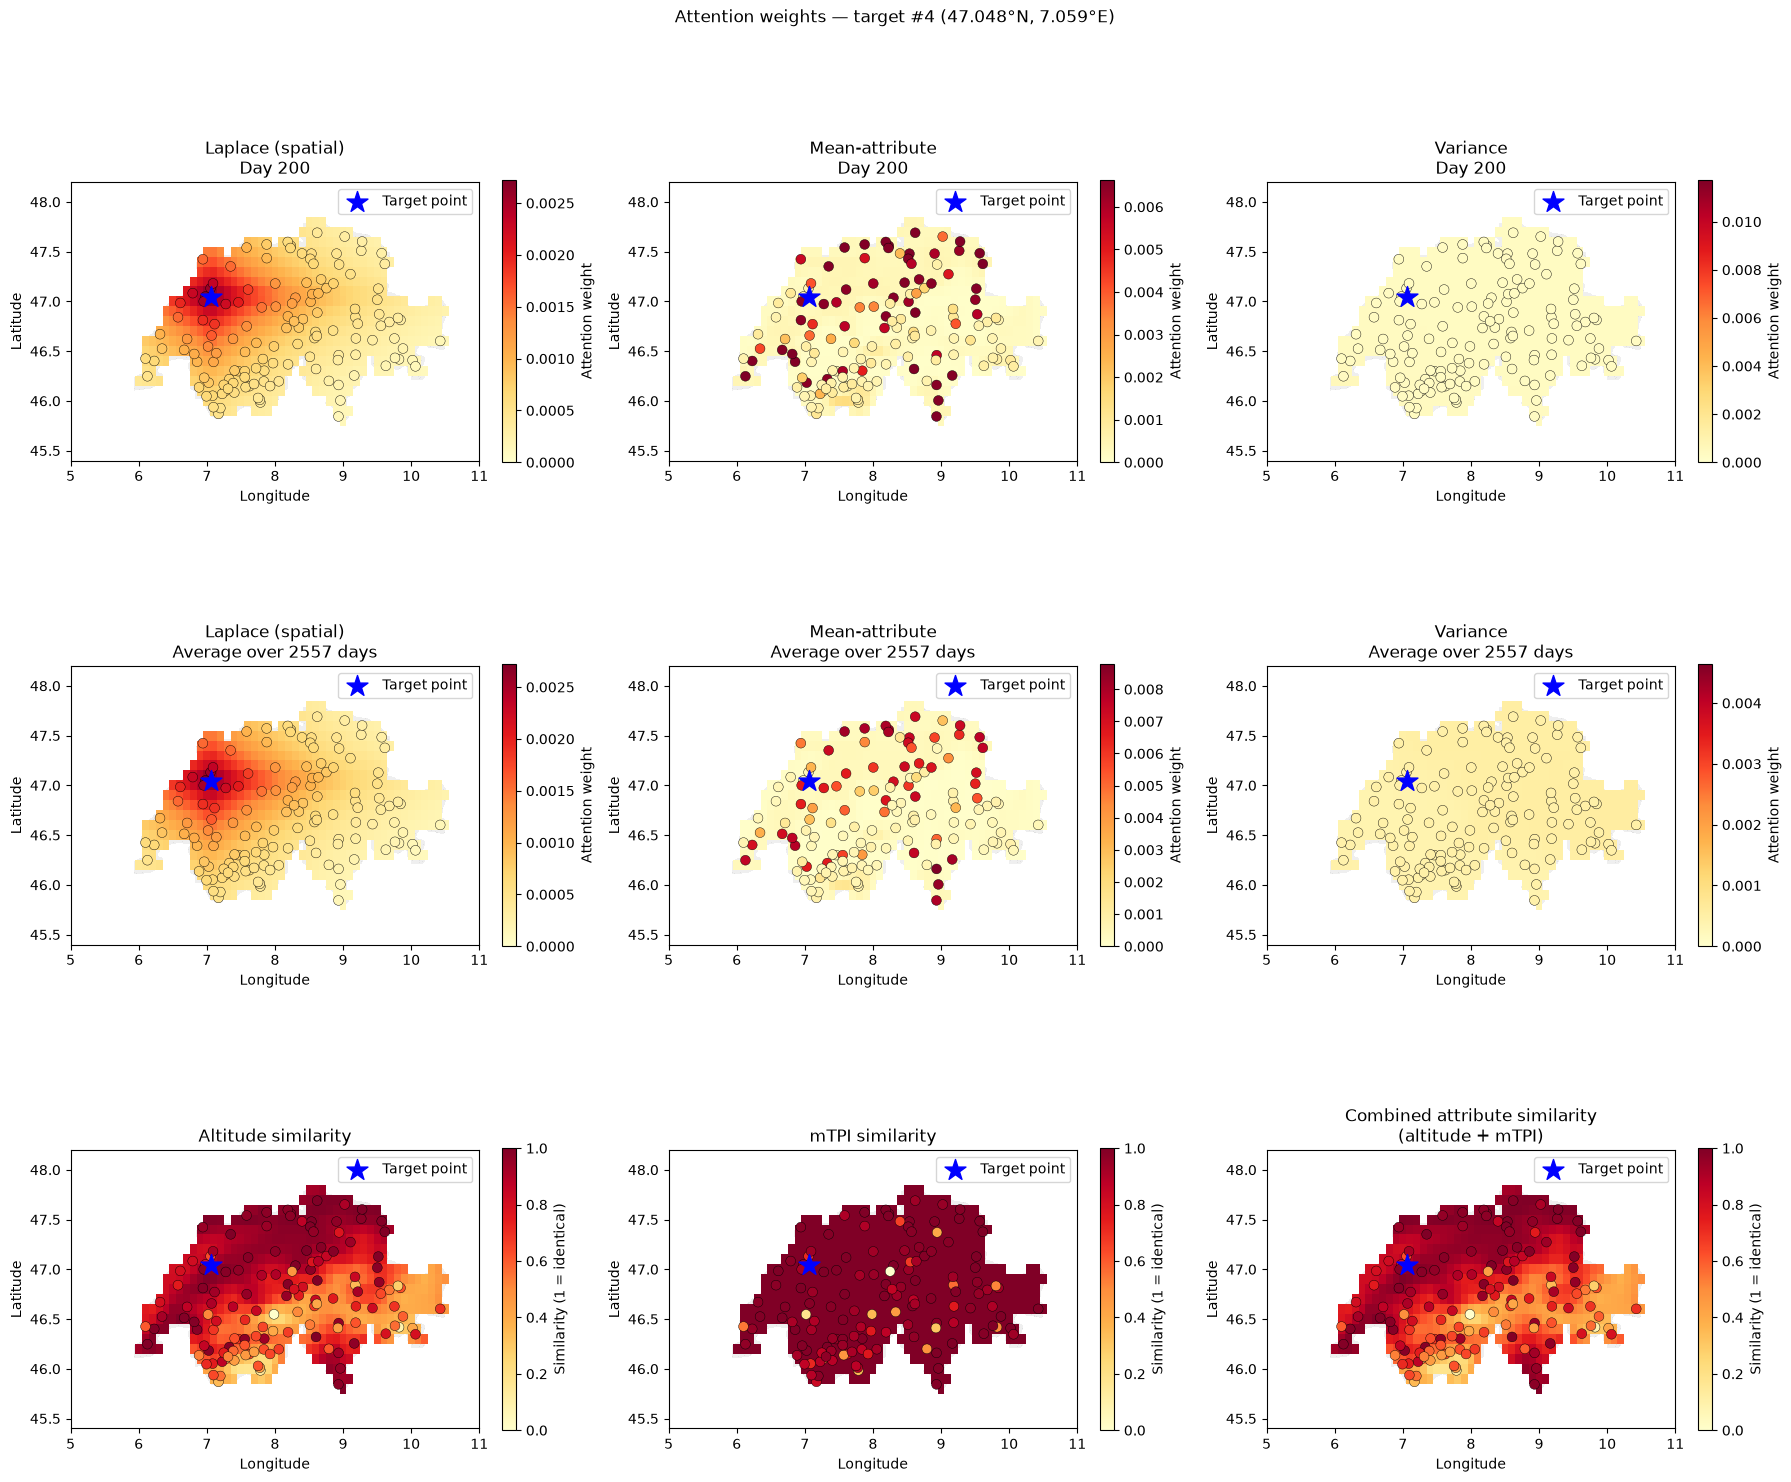

In [27]:
from importlib import reload
import visualization as vis
vis = reload(vis)
from visualization import get_lat_lon_arrays, find_target_point, plot_attention_maps

# Some predefined reference points for which attention can be visualized:
LOCATIONS = {
    'Zurich':   (47.376, 8.541),
    'Geneva':   (46.204, 6.143),
    'Neuchatel':(46.990, 6.929), 
    'Bern':     (46.948, 7.447),
    'Zermatt':  (46.020, 7.749),
    'Davos':    (46.803, 9.837),
    'Other':    (47.249, 9.343),
}

context_lats, context_lons, target_lats, target_lons = vis.get_lat_lon_arrays(
    x_context, x_target_static, metadata
)

name = 'Neuchatel'  # Select the point for which the attention map should be displayed
lat, lon = LOCATIONS[name]
idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, target_lats, target_lons)
print(f"{name}: target_point_idx={idx}, matched ({matched_lat:.4f}°N, {matched_lon:.4f}°E), {dist_km:.2f} km away")

SHOW_AVERAGE = True
SHOW_SIMILARITY = True

viz_lats_1d = np.linspace(metadata.lat_min, metadata.lat_max, 240)
viz_lons_1d = np.linspace(metadata.lon_min, metadata.lon_max, 370)

fig = vis.plot_attention_maps(
    model=model, x_context=x_context, y_context=y_context,
    x_target_static=x_target_static, day_idx=200, target_point_idx=idx,
    grid_shape=grid_shape, metadata=metadata, device=device,
    y_target_flat=None,
    show_average=SHOW_AVERAGE,
    show_similarity=SHOW_SIMILARITY,
    viz_grid_lats_1d=viz_lats_1d,
    viz_grid_lons_1d=viz_lons_1d,
    swiss_border_lons_2d=border_lons_2d,
    swiss_border_lats_2d=border_lats_2d,
    swiss_valid_2d=border_valid_2d,
)

## Summary

This notebook demonstrates how to:
1. Load trained SMACNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Build the combined ERA5 + PeakWeather train context for each holdout day
4. **Per-fold:** Generate predictions at the 35 held-out PeakWeather test stations
   and plot a scatter of observed vs predicted temperatures for a representative day
5. **Combined across all folds:** Since holdout periods are non-overlapping,
   predictions from all folds are concatenated to produce a unified evaluation:
   - Per-station error maps (MAE, RMSE, Bias)
   - Uncertainty calibration (predicted σ vs actual MAE per station)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to regression kriging baseline
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration — the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarises miscalibration
